# What is a Flowsheet? (Basic)

**Prerequisites:** JAX fundamentals (tutorials 01-06), basic chemical engineering (mass/energy balances, unit operations)

**Learning Objectives:**
- Understand what a process flowsheet represents physically
- Learn the meaning of boxes (equipment), arrows (streams), and numbers (flows)
- See how streams are represented in code
- Connect the visual diagram to numerical simulation

---

## What is a Process Flowsheet?

A **process flowsheet** (or **Process Flow Diagram**, PFD) is a visual representation of a chemical process. It shows:

1. **Equipment** (unit operations) - drawn as shapes/symbols
2. **Streams** - drawn as arrows connecting equipment
3. **Flow information** - numbers on streams indicating composition, temperature, pressure

Think of a flowsheet as a "map" of how materials flow through a chemical plant.

## A Simple Example: Heating a Stream

Let's start with the simplest possible flowsheet: heating a liquid stream.

```
    Stream 1              Stream 2
    ────────►  ┌───────┐  ────────►
    Cold feed  │ Heater│  Hot product
    ────────►  └───────┘  ────────►
```

**Physical interpretation:**
- A cold liquid enters the heater
- Heat is added (from steam, electricity, etc.)
- A hot liquid exits

**What does this diagram tell us?**
- There is ONE piece of equipment (the heater)
- There are TWO streams (inlet and outlet)
- Material flows from left to right

## What is a Stream?

A **stream** is a flowing mixture of chemicals. To fully describe a stream, we need:

| Property | Symbol | Units | What it means |
|----------|--------|-------|---------------|
| Molar flow of each species | $F_i$ | mol/s | How much of species $i$ is flowing |
| Temperature | $T$ | K | How hot the stream is |
| Pressure | $P$ | Pa | The force per area in the stream |

For example, a stream might be described as:
- $F_{\text{water}} = 100$ mol/s
- $F_{\text{ethanol}} = 20$ mol/s  
- $T = 350$ K
- $P = 101325$ Pa (1 atm)

This completely specifies the stream's state.

## Representing Streams in Code

Let's see how to represent streams in Python. We'll show three approaches:

1. **Raw Python** - a simple dictionary
2. **NumPy/JAX arrays** - for numerical computation
3. **difflow** - the library's approach

All three represent the same physical reality!

In [1]:
# Setup
import os
os.environ['JAX_PLATFORM_NAME'] = 'cpu'

import jax.numpy as jnp
import jax
jax.config.update("jax_enable_x64", True)

In [2]:
# Approach 1: Raw Python dictionary
# Simplest representation - just store the numbers

stream_raw = {
    'F_water': 100.0,     # mol/s
    'F_ethanol': 20.0,    # mol/s
    'T': 350.0,           # K
    'P': 101325.0,        # Pa
}

print("Stream (raw Python dictionary):")
for key, value in stream_raw.items():
    print(f"  {key} = {value}")

Stream (raw Python dictionary):
  F_water = 100.0
  F_ethanol = 20.0
  T = 350.0
  P = 101325.0


In [3]:
# Approach 2: JAX arrays in a dictionary
# This enables automatic differentiation!

stream_jax = {
    'F_water': jnp.array(100.0),
    'F_ethanol': jnp.array(20.0),
    'T': jnp.array(350.0),
    'P': jnp.array(101325.0),
}

print("Stream (JAX arrays in dictionary):")
for key, value in stream_jax.items():
    print(f"  {key} = {value}")

# Compute total molar flow
total_flow = stream_jax['F_water'] + stream_jax['F_ethanol']
print(f"\nTotal molar flow = {total_flow} mol/s")

Metal device set to: Apple M4 Pro
Stream (JAX arrays in dictionary):
  F_water = 100.0
  F_ethanol = 20.0
  T = 350.0
  P = 101325.0

Total molar flow = 120.0 mol/s


W0000 00:00:1766255687.641831 18567125 mps_client.cc:510] WARNING: JAX Apple GPU support is experimental and not all JAX functionality is correctly supported!
I0000 00:00:1766255687.651894 18567125 service.cc:145] XLA service 0x600000854500 initialized for platform METAL (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1766255687.651904 18567125 service.cc:153]   StreamExecutor device (0): Metal, <undefined>
I0000 00:00:1766255687.652819 18567125 mps_client.cc:406] Using Simple allocator.
I0000 00:00:1766255687.652825 18567125 mps_client.cc:384] XLA backend will use up to 51539132416 bytes on device 0 for SimpleAllocator.


In [4]:
# Approach 3: Using difflow's make_stream function
# This is a convenient wrapper that standardizes the format

from difflow import make_stream, get_flows, total_flow as calc_total_flow

stream_difflow = make_stream(
    flows={'water': 100.0, 'ethanol': 20.0},  # Note: no 'F_' prefix needed
    T=350.0,
    P=101325.0,
)

print("Stream (difflow):")
print(f"  Full stream dict: {stream_difflow}")
print(f"\n  Species flows: {get_flows(stream_difflow)}")
print(f"  Temperature: {stream_difflow['T']} K")
print(f"  Pressure: {stream_difflow['P']} Pa")
print(f"  Total flow: {calc_total_flow(stream_difflow)} mol/s")

Stream (difflow):
  Full stream dict: {'F_water': Array(100., dtype=float64), 'F_ethanol': Array(20., dtype=float64), 'T': Array(350., dtype=float64), 'P': Array(101325., dtype=float64)}

  Species flows: {'water': Array(100., dtype=float64), 'ethanol': Array(20., dtype=float64)}
  Temperature: 350.0 K
  Pressure: 101325.0 Pa
  Total flow: 120.0 mol/s


**Key insight:** All three approaches represent the same physical stream. difflow uses JAX arrays in dictionaries, which:
- Are human-readable (species names as keys)
- Work with JAX's automatic differentiation
- Can be passed through unit operations

## What is a Unit Operation?

A **unit operation** is a piece of equipment that transforms streams. Mathematically, it's a function:

$$\text{outlet stream(s)} = f(\text{inlet stream(s)}, \text{parameters})$$

For our heater example:
- **Input:** Cold stream (known composition, temperature, pressure)
- **Parameters:** Heat duty $Q$ (watts) or outlet temperature $T_{out}$
- **Output:** Hot stream (same composition, higher temperature)

Let's implement a simple heater.

In [5]:
# A simple heater - raw implementation
# This shows what's happening "under the hood"

def simple_heater_raw(inlet, Q, Cp_mixture):
    """
    Heat a stream by adding heat duty Q.
    
    Energy balance: Q = F_total * Cp * (T_out - T_in)
    Rearranging:    T_out = T_in + Q / (F_total * Cp)
    
    Args:
        inlet: Input stream dictionary
        Q: Heat duty in watts (J/s)
        Cp_mixture: Average heat capacity in J/(mol·K)
    
    Returns:
        Output stream dictionary
    """
    # Get total molar flow
    F_total = inlet['F_water'] + inlet['F_ethanol']
    
    # Energy balance to find outlet temperature
    T_out = inlet['T'] + Q / (F_total * Cp_mixture)
    
    # Create outlet stream (flows unchanged, T increased)
    outlet = {
        'F_water': inlet['F_water'],
        'F_ethanol': inlet['F_ethanol'],
        'T': T_out,
        'P': inlet['P'],  # Assume no pressure drop
    }
    
    return outlet


# Use the heater
inlet_stream = {
    'F_water': 100.0,
    'F_ethanol': 20.0,
    'T': 300.0,  # K (cold)
    'P': 101325.0,
}

Q = 50000.0  # 50 kW heat duty
Cp = 75.0    # Approximate Cp for liquid water in J/(mol·K)

outlet_stream = simple_heater_raw(inlet_stream, Q, Cp)

print("Heater Example (raw implementation)")
print("=" * 40)
print(f"Inlet T  = {inlet_stream['T']:.1f} K")
print(f"Heat duty = {Q/1000:.1f} kW")
print(f"Outlet T = {outlet_stream['T']:.1f} K")
print(f"\nTemperature rise = {outlet_stream['T'] - inlet_stream['T']:.1f} K")

Heater Example (raw implementation)
Inlet T  = 300.0 K
Heat duty = 50.0 kW
Outlet T = 305.6 K

Temperature rise = 5.6 K


In [6]:
# Now with JAX arrays - enables differentiation!

def simple_heater_jax(inlet, Q, Cp_mixture):
    """Same heater, but using JAX arrays."""
    F_total = inlet['F_water'] + inlet['F_ethanol']
    T_out = inlet['T'] + Q / (F_total * Cp_mixture)
    
    return {
        'F_water': inlet['F_water'],
        'F_ethanol': inlet['F_ethanol'],
        'T': T_out,
        'P': inlet['P'],
    }


# Create inlet with JAX arrays
inlet_jax = {
    'F_water': jnp.array(100.0),
    'F_ethanol': jnp.array(20.0),
    'T': jnp.array(300.0),
    'P': jnp.array(101325.0),
}

Q_jax = jnp.array(50000.0)
Cp_jax = jnp.array(75.0)

outlet_jax = simple_heater_jax(inlet_jax, Q_jax, Cp_jax)

print("Heater Example (JAX implementation)")
print("=" * 40)
print(f"Inlet T  = {float(inlet_jax['T']):.1f} K")
print(f"Outlet T = {float(outlet_jax['T']):.1f} K")

Heater Example (JAX implementation)
Inlet T  = 300.0 K
Outlet T = 305.6 K


In [7]:
# Using difflow's Heater
from difflow import Heater, HeaterParams

# Create heater with Cp parameter (simplified - no thermo needed for basic use)
heater = Heater(HeaterParams(Cp=75.0))

# Create inlet stream with difflow
inlet_difflow = make_stream(
    flows={'water': 100.0, 'ethanol': 20.0},
    T=300.0,
    P=101325.0,
)

# Heat the stream (pass duty as override)
outlet_difflow, info = heater(inlet_difflow, duty=50000.0)

print("Heater Example (difflow implementation)")
print("=" * 40)
print(f"Inlet T  = {float(inlet_difflow['T']):.1f} K")
print(f"Outlet T = {float(outlet_difflow['T']):.1f} K")
print(f"Heat duty = {float(info['Q'])/1000:.1f} kW")

Heater Example (difflow implementation)
Inlet T  = 300.0 K
Outlet T = 305.6 K
Heat duty = 50.0 kW


**Observation:** All three implementations give the same result! The difflow version:
- Uses proper thermodynamic properties
- Returns additional information (like heat duty)
- Is already integrated with the flowsheet solver

## Visualizing a Flowsheet

A picture is worth a thousand numbers. Let's create a simple visualization of our heater flowsheet.

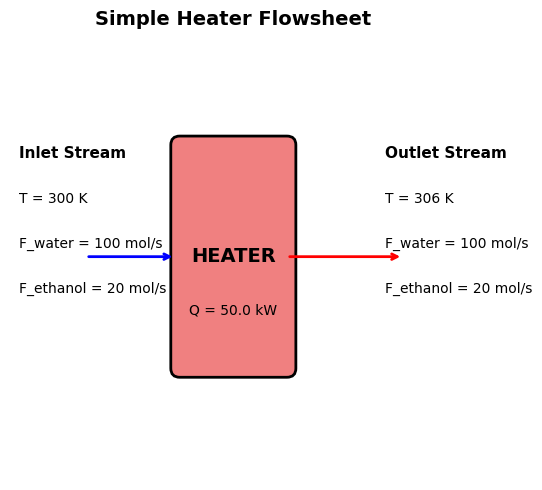

In [22]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def draw_heater_flowsheet(inlet, outlet, Q):
    """Draw a simple heater flowsheet diagram."""
    fig, ax = plt.subplots(1, 1, figsize=(12, 5))
    
    # Draw heater box
    heater_box = patches.FancyBboxPatch(
        (0.38, 0.25), 0.24, 0.5,
        boxstyle="round,pad=0.02",
        facecolor='lightcoral',
        edgecolor='black',
        linewidth=2,
    )
    ax.add_patch(heater_box)
    ax.text(0.5, 0.5, 'HEATER', ha='center', va='center', fontsize=14, fontweight='bold')
    ax.text(0.5, 0.38, f'Q = {Q/1000:.1f} kW', ha='center', va='center', fontsize=10)
    
    # Draw inlet arrow
    ax.annotate('', xy=(0.37, 0.5), xytext=(0.17, 0.5),
                arrowprops=dict(arrowstyle='->', lw=2, color='blue'))
    ax.text(0.02, 0.72, 'Inlet Stream', fontsize=11, fontweight='bold')
    ax.text(0.02, 0.62, f'T = {inlet["T"]:.0f} K', fontsize=10)
    ax.text(0.02, 0.52, f'F_water = {inlet["F_water"]:.0f} mol/s', fontsize=10)
    ax.text(0.02, 0.42, f'F_ethanol = {inlet["F_ethanol"]:.0f} mol/s', fontsize=10)
    
    # Draw outlet arrow
    ax.annotate('', xy=(0.88, 0.5), xytext=(0.62, 0.5),
                arrowprops=dict(arrowstyle='->', lw=2, color='red'))
    ax.text(0.84, 0.72, 'Outlet Stream', fontsize=11, fontweight='bold')
    ax.text(0.84, 0.62, f'T = {outlet["T"]:.0f} K', fontsize=10)
    ax.text(0.84, 0.52, f'F_water = {outlet["F_water"]:.0f} mol/s', fontsize=10)
    ax.text(0.84, 0.42, f'F_ethanol = {outlet["F_ethanol"]:.0f} mol/s', fontsize=10)
    
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title('Simple Heater Flowsheet', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    return fig

# Draw the flowsheet
fig = draw_heater_flowsheet(
    inlet={'F_water': 100.0, 'F_ethanol': 20.0, 'T': 300.0},
    outlet={'F_water': 100.0, 'F_ethanol': 20.0, 'T': float(outlet_jax['T'])},
    Q=50000.0
)


## Key Concepts Summary

| Concept | Physical Meaning | Code Representation |
|---------|-----------------|---------------------|
| **Stream** | Flowing mixture of chemicals | Dictionary with flows, T, P |
| **Unit Operation** | Equipment that transforms streams | Function: `outlet = f(inlet, params)` |
| **Flowsheet** | Connected network of equipment | Sequence of function calls |
| **Flow rate** $F_i$ | Amount of species $i$ passing per second | `stream['F_species']` in mol/s |
| **Temperature** $T$ | Thermal energy of the stream | `stream['T']` in K |
| **Pressure** $P$ | Force per unit area | `stream['P']` in Pa |

## Try It Yourself!

Modify the code below to explore how the heater behaves.

In [9]:
# Exercise 1: What happens if you double the heat duty?
# Try changing Q from 50000 to 100000 and re-run

Q_test = 50000.0  # <-- Change this value!

outlet_test = simple_heater_jax(inlet_jax, jnp.array(Q_test), Cp_jax)
print(f"Heat duty: {Q_test/1000:.1f} kW")
print(f"Outlet temperature: {float(outlet_test['T']):.1f} K")
print(f"Temperature rise: {float(outlet_test['T']) - float(inlet_jax['T']):.1f} K")

Heat duty: 50.0 kW
Outlet temperature: 305.6 K
Temperature rise: 5.6 K


In [10]:
# Exercise 2: What happens if you increase the flow rate?
# More flow means less temperature rise for the same heat duty

F_water_test = 100.0  # <-- Try 200, 500, etc.

inlet_test = {
    'F_water': jnp.array(F_water_test),
    'F_ethanol': jnp.array(20.0),
    'T': jnp.array(300.0),
    'P': jnp.array(101325.0),
}

outlet_test = simple_heater_jax(inlet_test, jnp.array(50000.0), Cp_jax)
print(f"Water flow rate: {F_water_test} mol/s")
print(f"Total flow rate: {F_water_test + 20.0} mol/s")
print(f"Outlet temperature: {float(outlet_test['T']):.1f} K")
print(f"Temperature rise: {float(outlet_test['T']) - 300.0:.1f} K")

Water flow rate: 100.0 mol/s
Total flow rate: 120.0 mol/s
Outlet temperature: 305.6 K
Temperature rise: 5.6 K


## End-of-Tutorial Problems

### Problem 1: Stream Properties
A stream contains:
- Methane: 50 mol/s
- Ethane: 30 mol/s
- Propane: 20 mol/s

Calculate:
a) The total molar flow rate
b) The mole fraction of each component
c) Create this stream using `make_stream` with T=298 K and P=500000 Pa

In [11]:
# Your solution here

# a) Total molar flow rate
F_total = None  # Calculate this

# b) Mole fractions
y_methane = None  # Calculate this
y_ethane = None
y_propane = None

# c) Create stream with make_stream
# natural_gas = make_stream(...)

### Problem 2: Cooler Design
Modify the `simple_heater_jax` function to create a `simple_cooler_jax` function that:
- Takes a hot inlet stream and a heat removal rate Q (negative value)
- Returns a cooled outlet stream

Test it by cooling a stream from 400 K to approximately 350 K.

In [12]:
# Your solution here

def simple_cooler_jax(inlet, Q, Cp_mixture):
    """Cool a stream by removing heat duty Q (Q should be negative)."""
    # Your code here
    pass

### Problem 3: Thinking Question
Why do we use dictionaries with string keys (like `'F_water'`) instead of just arrays of numbers?

Think about:
- Readability
- Error prevention
- Flexibility when adding/removing species

*Your answer here:*



---

## Next Steps

In the next notebook (**[00b: What is a Flowsheet? Intermediate](./00b_what_is_a_flowsheet_intermediate.ipynb)**), we'll explore:
- The mathematical view: flowsheets as systems of equations
- How streams become "shared variables" between units
- Degrees of freedom analysis

This will deepen your understanding of what the computer is actually solving when you simulate a flowsheet.